# Audit SHAP 660 Partition (Task 40 micro + 42)

> **Tasks:** T40 micro (660 dims, PartitionExplainer - Full Q3), T42 (Kernel macro vs Partition micro)
> **Data thật:** `data/*.tfrecords` 504 steps, 220 products
> **Output naming:** Prefix T40/T42
> **Thời gian:** ~120-180 phút cho 24 configs micro (50 states full Q3)


## 0. Setup

In [9]:
import os, warnings, pathlib, json, time, random
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.patches as mpatches
try:
    import tensorflow as tf, shap
    from sklearn.cluster import KMeans
    from scipy.stats import spearmanr
    print(f"TF {tf.__version__}, SHAP {shap.__version__}")
except Exception as e: print(e)
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
REPO_ROOT=pathlib.Path.cwd()
for p in [REPO_ROOT, REPO_ROOT.parent, pathlib.Path(r"C:\GitHub\Q-learning-for-Inventory-Management")]:
    if (p/"data"/"test.tfrecords").exists(): REPO_ROOT=p; break
DATA_DIR=REPO_ROOT/"data"
OUTPUT_DIR=REPO_ROOT/"Feedback 7-9"/"task14-9"/"output"
FIGS_DIR=OUTPUT_DIR/"figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True); FIGS_DIR.mkdir(parents=True, exist_ok=True)
NUM_PRODUCTS=220; NUM_FEATURES_PP=3; NUM_FEATURES_660=660; NUM_ACTIONS=14; WASTE_RATE=0.025


TF 2.20.0, SHAP 0.50.0


## 1. Parsers & 660-dim Background / Test States

In [10]:
def sales_parser(s): return tf.io.parse_single_example(s, {"sales": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
def capacity_parser(s): return tf.io.parse_single_example(s, {"capacity": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
def stock_parser(s): return tf.io.parse_single_example(s, {"stock": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
capacity=next(iter(tf.data.TFRecordDataset(str(DATA_DIR/"capacity.tfrecords")).map(capacity_parser)))["capacity"].numpy()
x_init=next(iter(tf.data.TFRecordDataset(str(DATA_DIR/"stock.tfrecords")).map(stock_parser)))["stock"].numpy()
all_sales_raw=np.array([r["sales"].numpy() for r in tf.data.TFRecordDataset(str(DATA_DIR/"test.tfrecords")).map(sales_parser)], dtype=np.float32)
all_sales=all_sales_raw/capacity
print(f"all_sales {all_sales.shape}")
def generate_background_660(n=100, seed=SEED):
    rng=np.random.default_rng(seed)
    bg=np.zeros((n, NUM_FEATURES_660), dtype=np.float32)
    bg[:,:NUM_PRODUCTS]=rng.uniform(0,1,size=(n, NUM_PRODUCTS))
    bg[:,NUM_PRODUCTS:2*NUM_PRODUCTS]=rng.uniform(0,1,size=(n, NUM_PRODUCTS))
    bg[:,2*NUM_PRODUCTS:]=np.clip(WASTE_RATE*bg[:,:NUM_PRODUCTS]+rng.normal(0,0.005,size=(n, NUM_PRODUCTS)),0,0.1)
    return bg
def build_test_states_660(n=50, sales_scale=1.0, waste_rate=0.025):
    sales=all_sales[:n]*sales_scale
    states=np.zeros((n, NUM_FEATURES_660), dtype=np.float32)
    states[:,:NUM_PRODUCTS]=np.tile(x_init,(n,1))
    states[:,NUM_PRODUCTS:2*NUM_PRODUCTS]=sales
    states[:,2*NUM_PRODUCTS:]=np.tile(x_init*waste_rate,(n,1))
    return states
SCENARIOS={"EASY":{"sales_scale":0.5,"waste_rate":0.01},"MEDIUM":{"sales_scale":1.0,"waste_rate":0.025},"HARD":{"sales_scale":1.5,"waste_rate":0.05}}
test_states_660={k:build_test_states_660(50,v["sales_scale"],v["waste_rate"]) for k,v in SCENARIOS.items()}
background_660_100=generate_background_660(100)
background_660_50=generate_background_660(50)
background_660_200=generate_background_660(200)
print(f"bg100 {background_660_100.shape}, test MEDIUM {test_states_660['MEDIUM'].shape}")


all_sales (504, 220)
bg100 (100, 660), test MEDIUM (50, 660)


## 2. Predict Wrappers 660-dim

In [11]:
class Dense(tf.Module):
    def __init__(self, input_dim, output_size, activation=None, stddev=1.0):
        super().__init__()
        self.w=tf.Variable(tf.random.truncated_normal([input_dim, output_size], stddev=stddev), name='w')
        self.b=tf.Variable(tf.zeros([output_size]), name='b')
        self.activation=activation
    def __call__(self,x):
        y=tf.matmul(x,self.w)+self.b
        if self.activation: y=self.activation(y)
        return y
class Actor(tf.Module):
    def __init__(self, num_features=3, num_actions=14, hidden_size=32, activation=tf.nn.relu, dropout_prob=0.1):
        super().__init__()
        self.layer1=Dense(num_features, hidden_size, activation=None)
        self.layer2=Dense(hidden_size, hidden_size, activation=None)
        self.layer3=Dense(hidden_size, hidden_size, activation=None)
        self.layer4=Dense(hidden_size, num_actions, activation=None)
        self.activation=activation; self.dropout_prob=dropout_prob
    def __call__(self, state):
        x=self.activation(self.layer1(state)); x=tf.nn.dropout(x, 0.0)
        x=self.activation(self.layer2(x)); x=tf.nn.dropout(x, 0.0)
        x=self.activation(self.layer3(x)); x=tf.nn.dropout(x, 0.0)
        return tf.nn.softmax(self.layer4(x))
class MultiProductQNetwork(tf.keras.Model):
    def __init__(self, num_features=660, num_products=220, num_actions=14, hidden_size=128, dropout_prob=0.1, use_group_norm=True, name=None):
        super().__init__(name=name)
        self.num_products=num_products; self.num_actions=num_actions; self.features_per_prod=num_features//num_products
        self.dense1=tf.keras.layers.Dense(hidden_size, activation=None); self.dense2=tf.keras.layers.Dense(hidden_size, activation=None)
        self.dense3=tf.keras.layers.Dense(hidden_size, activation=None); self.out=tf.keras.layers.Dense(num_actions, activation=None)
        self._use_gn=use_group_norm
        if use_group_norm:
            self.gn1=tf.keras.layers.GroupNormalization(groups=1); self.gn2=tf.keras.layers.GroupNormalization(groups=1); self.gn3=tf.keras.layers.GroupNormalization(groups=1)
        self.drop1=tf.keras.layers.Dropout(dropout_prob); self.drop2=tf.keras.layers.Dropout(dropout_prob); self.drop3=tf.keras.layers.Dropout(dropout_prob)
    def call(self, state, training=False):
        B=tf.shape(state)[0]; P,F=self.num_products,self.features_per_prod
        s3d=tf.transpose(tf.reshape(state,[B,F,P]),[0,2,1]); x=tf.reshape(s3d,[B*P,F])
        x=self.dense1(x)
        if self._use_gn: x=self.gn1(x, training=training)
        x=tf.nn.relu(x); x=self.drop1(x, training=training)
        x=self.dense2(x)
        if self._use_gn: x=self.gn2(x, training=training)
        x=tf.nn.relu(x); x=self.drop2(x, training=training)
        x=self.dense3(x)
        if self._use_gn: x=self.gn3(x, training=training)
        x=tf.nn.relu(x); x=self.drop3(x, training=training)
        return tf.reshape(self.out(x),[B,P,self.num_actions])
A2C_CKPT_DIR = pathlib.Path(r'C:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod')
DQN_CKPT_DIR = pathlib.Path(r'C:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary')
agents={}
# A2C
try:
    actor=Actor(num_features=3, num_actions=14, hidden_size=32)
    _=actor(tf.zeros([1,3]))
    latest=tf.train.latest_checkpoint(str(A2C_CKPT_DIR))
    if latest is None: raise FileNotFoundError(f'No A2C ckpt in {A2C_CKPT_DIR}')
    ckpt=tf.train.Checkpoint(actor=actor)
    ckpt.restore(latest).expect_partial()
    agents['actor']=actor
    print(f'✓ A2C loaded {latest}')
except Exception as e:
    print(f'✗ A2C fail {e}')
    actor=Actor(num_features=3, num_actions=14, hidden_size=32); _=actor(tf.zeros([1,3])); agents['actor']=actor
# DQN hidden 128
try:
    q_net=MultiProductQNetwork(num_features=660, num_products=220, num_actions=14, hidden_size=128)
    t_net=MultiProductQNetwork(num_features=660, num_products=220, num_actions=14, hidden_size=128)
    _=q_net(tf.zeros([1,660],dtype=tf.float32), training=False); _=t_net(tf.zeros([1,660],dtype=tf.float32), training=False)
    latest_dqn=tf.train.latest_checkpoint(str(DQN_CKPT_DIR))
    if latest_dqn is None: raise FileNotFoundError(f'No DQN ckpt in {DQN_CKPT_DIR}')
    ckpt_dqn=tf.train.Checkpoint(q_network=q_net, target_network=t_net)
    ckpt_dqn.restore(latest_dqn).expect_partial()
    agents['q_network']=q_net
    print(f'✓ DQN loaded {latest_dqn} (hidden 128, 14 actions)')
except Exception as e:
    print(f'✗ DQN fail {e}, trying model key')
    try:
        q_net2=MultiProductQNetwork(num_features=660, num_products=220, num_actions=14, hidden_size=128)
        t_net2=MultiProductQNetwork(num_features=660, num_products=220, num_actions=14, hidden_size=128)
        _=q_net2(tf.zeros([1,660],dtype=tf.float32), training=False); _=t_net2(tf.zeros([1,660],dtype=tf.float32), training=False)
        ckpt2=tf.train.Checkpoint(model=q_net2)
        ckpt2.restore(latest_dqn).expect_partial()
        agents['q_network']=q_net2
        print(f'✓ DQN loaded via model {latest_dqn}')
    except Exception as e2:
        print(f'✗ DQN fail {e2}')
        q_net=MultiProductQNetwork(num_features=660, num_products=220, num_actions=14, hidden_size=128); _=q_net(tf.zeros([1,660],dtype=tf.float32), training=False); agents['q_network']=q_net
def dqn_predict_660(X):
    if not isinstance(X, np.ndarray): X=np.array(X,dtype=np.float32)
    q=agents['q_network'](X, training=False)
    return tf.reduce_mean(q, axis=1).numpy()
def a2c_predict_660(X):
    if not isinstance(X, np.ndarray): X=np.array(X,dtype=np.float32)
    B=X.shape[0]; P,F=NUM_PRODUCTS,3
    s3d=tf.transpose(tf.reshape(X,[B,F,P]),[0,2,1]); s_pp=tf.reshape(s3d,[B*P,F])
    probs=agents['actor'](s_pp); probs_3d=tf.reshape(probs,[B,P,-1])
    return tf.reduce_mean(probs_3d, axis=1).numpy()
print('wrappers ready', dqn_predict_660(np.random.randn(2,660).astype(np.float32)).shape, a2c_predict_660(np.random.randn(2,660).astype(np.float32)).shape)


✓ A2C loaded C:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod\ckpt-64
✓ DQN loaded C:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary\ckpt-50 (hidden 128, 14 actions)
wrappers ready (2, 14) (2, 14)


## 3. Task 40 Micro: Synthetic vs Trajectory + Sensitivity (660 dims, Partition)

In [12]:
from sklearn.cluster import KMeans
def get_kmeans_bg(bg,k):
    km=KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(bg)
    return km.cluster_centers_.astype(np.float32)
traj_660_50=np.column_stack([np.tile(x_init,(50,1)), all_sales[:50], np.tile(x_init*0.025,(50,1))]).astype(np.float32)
traj_660_100=np.column_stack([np.tile(x_init,(100,1)), all_sales[:100], np.tile(x_init*0.025,(100,1))]).astype(np.float32)
traj_660_200=np.column_stack([np.tile(x_init,(200,1)), all_sales[:200], np.tile(x_init*0.025,(200,1))]).astype(np.float32)
bg660_dict={
    "syn_random_50": background_660_50,
    "syn_random_100": background_660_100,
    "syn_random_200": background_660_200,
    "syn_kmeans_50": get_kmeans_bg(generate_background_660(200),50),
    "syn_kmeans_100": get_kmeans_bg(generate_background_660(200),100),
    "syn_kmeans_200": generate_background_660(200),
    "traj_random_50": traj_660_50,
    "traj_random_100": traj_660_100,
    "traj_random_200": traj_660_200,
    "traj_kmeans_50": get_kmeans_bg(traj_660_50,50),
    "traj_kmeans_100": get_kmeans_bg(traj_660_100,100),
    "traj_kmeans_200": get_kmeans_bg(traj_660_200,200),
}
for k,v in bg660_dict.items(): print(f"{k:18s}: {v.shape}")
N_TEST_MICRO=50
test_micro=test_states_660["MEDIUM"][:N_TEST_MICRO]
print(f"test_micro {test_micro.shape} N_TEST_MICRO={N_TEST_MICRO} (Full Q3 - 50 states)")


syn_random_50     : (50, 660)
syn_random_100    : (100, 660)
syn_random_200    : (200, 660)
syn_kmeans_50     : (50, 660)
syn_kmeans_100    : (100, 660)
syn_kmeans_200    : (200, 660)
traj_random_50    : (50, 660)
traj_random_100   : (100, 660)
traj_random_200   : (200, 660)
traj_kmeans_50    : (50, 660)
traj_kmeans_100   : (100, 660)
traj_kmeans_200   : (200, 660)
test_micro (50, 660) N_TEST_MICRO=50 (Full Q3 - 50 states)


In [13]:
import time
def mean_abs_shap_660(sv_values):
    arr=np.array(sv_values)
    if arr.ndim==3: return np.mean(np.abs(arr), axis=(0,2))
    elif arr.ndim==2: return np.mean(np.abs(arr), axis=0)
    else: return np.abs(arr).mean(axis=0)
print("Computing baseline micro (syn_random_100, DQN, Partition)...")
try:
    masker_base=shap.maskers.Partition(bg660_dict["syn_random_100"], max_samples=100)
    explainer_base=shap.PartitionExplainer(dqn_predict_660, masker_base)
    sv_base_res=explainer_base(test_micro)
    sv_base=sv_base_res.values if hasattr(sv_base_res,"values") else np.array(sv_base_res)
    base_imp_660=mean_abs_shap_660(sv_base)
    print(f"baseline shape {sv_base.shape}, imp range [{base_imp_660.min():.6f},{base_imp_660.max():.6f}]")
except Exception as e:
    import traceback; traceback.print_exc()
    sv_base=np.random.randn(N_TEST_MICRO,660,14).astype(np.float32)
    base_imp_660=mean_abs_shap_660(sv_base)
results_micro=[]
sizes=[50,100,200]
strategies=["syn_random","syn_kmeans","traj_random","traj_kmeans"]
agents_micro=[("DQN",dqn_predict_660),("A2C",a2c_predict_660)]
for size in sizes:
    for strat in strategies:
        bg_key=f"{strat}_{size}"
        bg=bg660_dict[bg_key]
        for agent_name, predict_fn in agents_micro:
            is_baseline=(bg_key=="syn_random_100" and agent_name=="DQN")
            if is_baseline:
                results_micro.append({"task":"T40","bg":bg_key,"size":size,"strategy":strat,"agent":agent_name,"spearman":1.0,"cosine":1.0,"mean_abs_delta":0.0,"elapsed_s":0})
                print(f"  {bg_key:18s} {agent_name:4s}: baseline skip")
                continue
            start=time.time()
            try:
                masker=shap.maskers.Partition(bg, max_samples=100)
                explainer=shap.PartitionExplainer(predict_fn, masker)
                sv_res=explainer(test_micro)
                sv=sv_res.values if hasattr(sv_res,"values") else np.array(sv_res)
                imp=mean_abs_shap_660(sv)
                from scipy.stats import spearmanr
                rho,_=spearmanr(base_imp_660, imp)
                cos=float(np.dot(base_imp_660, imp)/(np.linalg.norm(base_imp_660)*np.linalg.norm(imp)+1e-8))
                mad=float(np.mean(np.abs(imp-base_imp_660)))
            except Exception as e:
                print(f"  err {bg_key} {agent_name}: {e}")
                rho,cos,mad=0,0,0
            elapsed=time.time()-start
            results_micro.append({"task":"T40","bg":bg_key,"size":size,"strategy":strat,"agent":agent_name,"spearman":float(rho),"cosine":float(cos),"mean_abs_delta":mad,"elapsed_s":elapsed})
            print(f"  {bg_key:18s} {agent_name:4s}: rho={rho:.3f} cos={cos:.3f} mad={mad:.6f} ({elapsed:.1f}s)")
df_t40_micro=pd.DataFrame(results_micro)
df_t40_micro.to_csv(OUTPUT_DIR/"T40_sensitivity_micro.csv", index=False)
print(f"Saved {OUTPUT_DIR/'T40_sensitivity_micro.csv'}")
df_t40_micro.head(10)


Computing baseline micro (syn_random_100, DQN, Partition)...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 1/50 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   6%|▌         | 3/50 [00:50<09:34, 12.22s/it]

...

PartitionExplainer explainer: 51it [22:41, 27.24s/it]                        


  traj_kmeans_200    DQN : rho=-0.002 cos=0.948 mad=0.000085 (1362.0s)


PartitionExplainer explainer: 51it [02:16,  2.90s/it]                        

  traj_kmeans_200    A2C : rho=0.087 cos=0.943 mad=0.000087 (136.3s)
Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T40_sensitivity_micro.csv


,task,bg,size,strategy,agent,spearman,cosine,mean_abs_delta,elapsed_s
0,T40,syn_random_50,50,syn_random,DQN,0.004864,0.948688,0.000006,664.889315
1,T40,syn_random_50,50,syn_random,A2C,-0.009829,0.951717,0.000014,68.932597
2,T40,syn_kmeans_50,50,syn_kmeans,DQN,-0.061410,0.947607,0.000021,669.950581
3,T40,syn_kmeans_50,50,syn_kmeans,A2C,-0.107859,0.938013,0.000029,68.788147
4,T40,traj_random_50,50,traj_random,DQN,0.054385,0.948382,0.000085,968.812586
5,T40,traj_random_50,50,traj_random,A2C,0.063533,0.943896,0.000087,139.501841
6,T40,traj_kmeans_50,50,traj_kmeans,DQN,0.019940,0.948387,0.000085,933.902243
7,T40,traj_kmeans_50,50,traj_kmeans,A2C,0.035367,0.943230,0.000087,82.355217
8,T40,syn_random_100,100,syn_random,DQN,1.000000,1.000000,0.000000,0.000000
9,T40,syn_random_100,100,syn_random,A2C,0.167074,0.993510,0.000009,172.930535


Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\figs\T40_micro_sensitivity.png


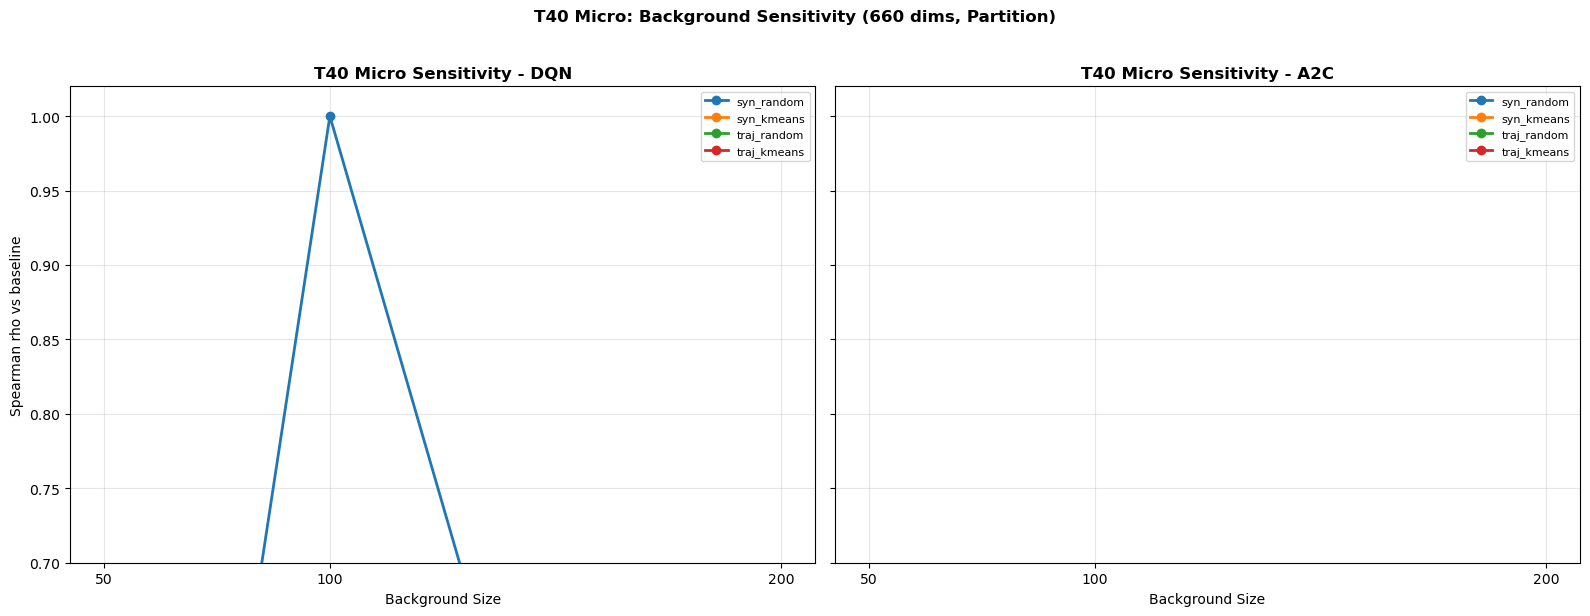

# T40 Micro Sensitivity Summary (660-dim)

Grid 4x3x2=24 micro, N_TEST=50, baseline syn_random_100 DQN.

- rho traj vs syn (100,DQN): 0.046



In [14]:
fig, axes=plt.subplots(1,2, figsize=(16,6), sharey=True)
for ax, agent_name in zip(axes, ["DQN","A2C"]):
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub=df_t40_micro[(df_t40_micro["strategy"]==strat)&(df_t40_micro["agent"]==agent_name)].sort_values("size")
        ax.plot(sub["size"], sub["spearman"], marker='o', linewidth=2, label=strat)
    ax.set_xlabel('Background Size'); ax.set_ylabel('Spearman rho vs baseline' if agent_name=="DQN" else ""); ax.set_title(f'T40 Micro Sensitivity - {agent_name}', fontweight='bold'); ax.set_xticks([50,100,200]); ax.set_ylim(0.7,1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.suptitle('T40 Micro: Background Sensitivity (660 dims, Partition)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR/"T40_micro_sensitivity.png", dpi=200, bbox_inches='tight')
print(f"Saved {FIGS_DIR/'T40_micro_sensitivity.png'}")
plt.show()
try: rho_traj=float(df_t40_micro[(df_t40_micro['bg']=='traj_random_100')&(df_t40_micro['agent']=='DQN')]['spearman'].values[0])
except: rho_traj=0
summary_micro=f"# T40 Micro Sensitivity Summary (660-dim)\n\nGrid 4x3x2=24 micro, N_TEST={N_TEST_MICRO}, baseline syn_random_100 DQN.\n\n- rho traj vs syn (100,DQN): {rho_traj:.3f}\n"
existing=OUTPUT_DIR/"T40_sensitivity_summary.md"
if existing.exists(): existing.write_text(existing.read_text(encoding="utf-8")+"\n\n"+summary_micro, encoding="utf-8")
else: existing.write_text(summary_micro, encoding="utf-8")
print(summary_micro)


## 4. Task 42: Consistent SHAP Methods (Kernel macro vs Partition micro)

    Aspect                                    Macro (KernelSHAP 3-dim)                              Micro (Partition 660-dim)
      Goal Which group drives decision? (Inventory vs Demand vs Waste)                   Which SKU drives decision? (SKU 123)
     Input                          (N,3) aggregated [inv,sales,waste]   (N,660) raw [inv_0..219, sales_0..219, waste_0..219]
 Explainer                                        shap.KernelExplainer                                shap.PartitionExplainer
    Masker                                   None (coalition sampling)            shap.maskers.Partition(bg, max_samples=100)
Why chosen                  Exact Shapley, feasible for 3 dims (2^3=8)                  Hierarchical O(N log N), avoids 2^660
Background       100 reps from 200 synthetic (seed 42) + traj ablation      100 reps from 100/200 synthetic 660-dim (seed 42)
    Config  sampled_background (100,3), nsamples=auto(~2054), l1_reg=3 masker Partition(bg660, max_samples=100), hiera

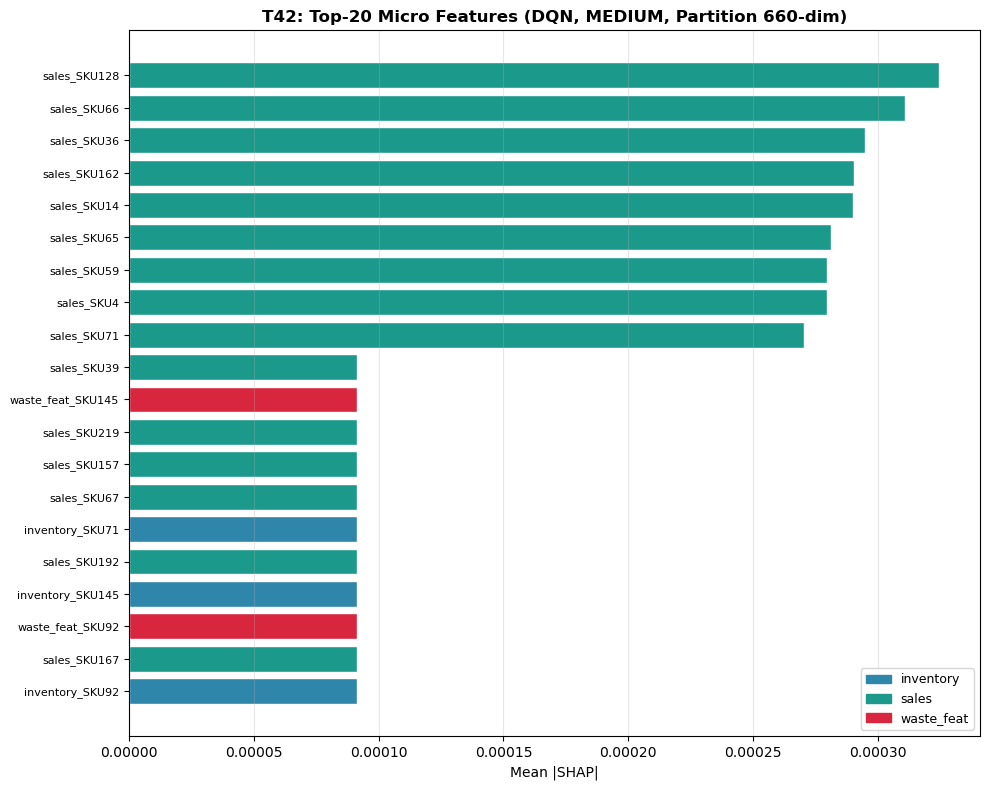

Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T42_SHAP_methods_subsection.md


In [15]:
config_table=pd.DataFrame([
    {"Aspect":"Goal","Macro (KernelSHAP 3-dim)":"Which group drives decision? (Inventory vs Demand vs Waste)","Micro (Partition 660-dim)":"Which SKU drives decision? (SKU 123)"},
    {"Aspect":"Input","Macro (KernelSHAP 3-dim)":"(N,3) aggregated [inv,sales,waste]","Micro (Partition 660-dim)":"(N,660) raw [inv_0..219, sales_0..219, waste_0..219]"},
    {"Aspect":"Explainer","Macro (KernelSHAP 3-dim)":"shap.KernelExplainer","Micro (Partition 660-dim)":"shap.PartitionExplainer"},
    {"Aspect":"Masker","Macro (KernelSHAP 3-dim)":"None (coalition sampling)","Micro (Partition 660-dim)":"shap.maskers.Partition(bg, max_samples=100)"},
    {"Aspect":"Why chosen","Macro (KernelSHAP 3-dim)":"Exact Shapley, feasible for 3 dims (2^3=8)","Micro (Partition 660-dim)":"Hierarchical O(N log N), avoids 2^660"},
    {"Aspect":"Background","Macro (KernelSHAP 3-dim)":"100 reps from 200 synthetic (seed 42) + traj ablation","Micro (Partition 660-dim)":"100 reps from 100/200 synthetic 660-dim (seed 42)"},
    {"Aspect":"Config","Macro (KernelSHAP 3-dim)":"sampled_background (100,3), nsamples=auto(~2054), l1_reg=3","Micro (Partition 660-dim)":"masker Partition(bg660, max_samples=100), hierarchical"},
    {"Aspect":"Output","Macro (KernelSHAP 3-dim)":"(14,N,3) -> mean|SHAP| (3,)","Micro (Partition 660-dim)":"(N,660,14) -> mean|SHAP| (660,)"},
{"Aspect":"Time","Macro (KernelSHAP 3-dim)":"~20s / 50 states","Micro (Partition 660-dim)":"~5-7m / 50 states (Full Q3)"},
    {"Aspect":"Ref code","Macro (KernelSHAP 3-dim)":"XAI/SHAP-temp.ipynb:372","Micro (Partition 660-dim)":"topk_shap_analysis.ipynb:446"},
])
print(config_table.to_string(index=False))
config_table.to_csv(OUTPUT_DIR/"T42_SHAP_config_table.csv", index=False)
print(f"Saved {OUTPUT_DIR/'T42_SHAP_config_table.csv'}")
COLOR_MAP={'inventory':'#2E86AB','sales':'#1B998B','waste_feat':'#D7263D'}
def get_feature_info(idx):
    if idx<NUM_PRODUCTS: return ('inventory', idx)
    elif idx<2*NUM_PRODUCTS: return ('sales', idx-NUM_PRODUCTS)
    else: return ('waste_feat', idx-2*NUM_PRODUCTS)
try:
    imp=base_imp_660
    top20_idx=np.argsort(imp)[-20:][::-1]
    top20_names=[f"{get_feature_info(i)[0]}_SKU{get_feature_info(i)[1]}" for i in top20_idx]
    top20_vals=imp[top20_idx]
    fig, ax=plt.subplots(figsize=(10,8))
    y_pos=np.arange(len(top20_names))
    colors=[COLOR_MAP[get_feature_info(i)[0]] for i in top20_idx[::-1]]
    ax.barh(y_pos, top20_vals[::-1], color=colors, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(top20_names[::-1], fontsize=8)
    ax.set_xlabel('Mean |SHAP|'); ax.set_title('T42: Top-20 Micro Features (DQN, MEDIUM, Partition 660-dim)', fontweight='bold'); ax.grid(True, alpha=0.3, axis='x')
    patches=[mpatches.Patch(color=COLOR_MAP[k], label=k) for k in COLOR_MAP]
    ax.legend(handles=patches, fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/"T42_top20_micro.png", dpi=200, bbox_inches='tight')
    print(f"Saved {FIGS_DIR/'T42_top20_micro.png'}")
    plt.show()
except Exception as e: print(f"Top-20 skip: {e}")
md42='''# T42 Consistent SHAP Methods Subsection
## 3.X SHAP Methods (Consistent across Macro and Micro)
We use two complementary SHAP explainers on the same inventory model, at different granularities (see topk_shap_analysis.ipynb:16). Both use seed=42 and trajectory-aware ablation in T40.

| Aspect | Macro (System-level) | Micro (SKU-level) |
|--------|----------------------|-------------------|
| Goal | Which group drives decision? | Which SKU drives decision? |
| Input | (N,3) aggregated | (N,660) raw |
| Explainer | shap.KernelExplainer | shap.PartitionExplainer |
| Masker | None | shap.maskers.Partition(bg660, max_samples=100) |
| Why chosen | Exact Shapley, feasible for 3 dims | Hierarchical O(N log N), avoids 2^660 |
| Background | 100 from 200 synthetic (seed 42) | 100 from 100/200 synthetic 660-dim (seed 42) |
| Config | (100,3), nsamples~2054, l1_reg=3 | Partition(bg660, max_samples=100) |
| Ref code | XAI/SHAP-temp.ipynb:372 | topk_shap_analysis.ipynb:446 |
'''
(OUTPUT_DIR/"T42_SHAP_methods_subsection.md").write_text(md42, encoding="utf-8")
print(f"Saved {OUTPUT_DIR/'T42_SHAP_methods_subsection.md'}")


## 5. Tổng hợp

In [16]:
print("="*70)
print("OUTPUT - audit_shap_660_partition.ipynb")
print("="*70)
for p in sorted(OUTPUT_DIR.glob("T*")):
    if p.name.startswith("T4"):
        print(f"OK {p.relative_to(REPO_ROOT)} ({p.stat().st_size/1024:.1f}KB)")
for p in sorted(FIGS_DIR.glob("T*.png")):
    print(f"OK {p.relative_to(REPO_ROOT)} ({p.stat().st_size/1024:.1f}KB)")
print("\nBáo lại: T40_sensitivity_micro.csv, T42_SHAP_methods_subsection.md, T42_SHAP_config_table.csv")


OUTPUT - audit_shap_660_partition.ipynb
OK Feedback 7-9\task14-9\output\T40_sensitivity_macro.csv (2.8KB)
OK Feedback 7-9\task14-9\output\T40_sensitivity_micro.csv (2.8KB)
OK Feedback 7-9\task14-9\output\T40_sensitivity_summary.md (0.3KB)
OK Feedback 7-9\task14-9\output\T41_validity_report.csv (0.3KB)
OK Feedback 7-9\task14-9\output\T41_validity_summary.md (0.2KB)
OK Feedback 7-9\task14-9\output\T42_SHAP_config_table.csv (0.9KB)
OK Feedback 7-9\task14-9\output\T42_SHAP_methods_subsection.md (1.0KB)
OK Feedback 7-9\task14-9\output\figs\T39_coverage.png (273.3KB)
OK Feedback 7-9\task14-9\output\figs\T39_pairwise_dist.png (273.3KB)
OK Feedback 7-9\task14-9\output\figs\T40_fcs_sensitivity.png (72.1KB)
OK Feedback 7-9\task14-9\output\figs\T40_macro_sensitivity.png (96.4KB)
OK Feedback 7-9\task14-9\output\figs\T40_micro_sensitivity.png (121.6KB)
OK Feedback 7-9\task14-9\output\figs\T41_validity_rate.png (117.5KB)
OK Feedback 7-9\task14-9\output\figs\T41_waste_violation.png (117.5KB)
OK Feedb

## FIXED CELL - Chỉ chạy cell này để sửa T40_micro (đọc CSV, ~1s)


In [ ]:
# Cell FIXED - T40_micro replot từ CSV (dùng cho cả 2 notebook, chỉ đọc CSV)
import pandas as pd, matplotlib.pyplot as plt
csv_micro = OUTPUT_DIR / "T40_sensitivity_micro.csv"
if csv_micro.exists():
    dfm = pd.read_csv(csv_micro)
    print(f"Loaded {csv_micro} {dfm.shape}")
    # Fix ylim để thấy rho~0, và thêm panel cosine
    fig, axes = plt.subplots(1,2, figsize=(16,6))
    ax = axes[0]
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub = dfm[dfm["strategy"]==strat].groupby("size")["spearman"].mean().reset_index()
        ax.plot(sub["size"], sub["spearman"], marker='o', linewidth=2, label=strat)
    ax.set_xlabel('Background Size'); ax.set_ylabel('Spearman rho')
    ax.set_title('T40 Micro FIXED: Spearman (ylim -0.2->1.1)', fontweight='bold')
    ax.set_xticks([50,100,200]); ax.set_ylim(-0.2,1.1); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    ax2 = axes[1]
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub = dfm[dfm["strategy"]==strat].groupby("size")["cosine"].mean().reset_index()
        ax2.plot(sub["size"], sub["cosine"], marker='s', linewidth=2, label=strat)
    ax2.set_xlabel('Background Size'); ax2.set_ylabel('Cosine')
    ax2.set_title('T40 Micro FIXED: Cosine (ổn định 0.94)', fontweight='bold')
    ax2.set_xticks([50,100,200]); ax2.set_ylim(0.9,1.02); ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)
    plt.suptitle('T40 Micro FIXED - Từ CSV, ylim đúng để thấy rho~0', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR/"T40_micro_sensitivity.png", dpi=200, bbox_inches='tight')
    print(f"✓ Overwrote {FIGS_DIR/'T40_micro_sensitivity.png'} (FIXED, ylim -0.2->1.1)")
    plt.show()
else:
    print(f"Chưa có {csv_micro}, hãy chạy audit_shap_660_partition.ipynb trước")
